In [5]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

csv_path = csv_path = 'img_align_celeba_small/list_attr_celeba_small.csv'
df = pd.read_csv(csv_path)

attributes = ['Attractive', 'Heavy_Makeup', 'Male', 'Pointy_Nose', 'Smiling', 'Young']

for attr in attributes:
    df[attr] = df[attr].replace(-1, 0)

train_df = df[df['Eval'] == 0].copy()
val_df = df[df['Eval'] == 1].copy()

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")

train_datagen = ImageDataGenerator(rescale=1. / 255, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1. / 255)

image_dir = 'img_align_celeba_small/img_align_celeba_small/'

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col=attributes,
    target_size=(128, 128),
    batch_size=32,
    class_mode='raw'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col=attributes,
    target_size=(128, 128),
    batch_size=32,
    class_mode='raw'
)

Training images: 49999
Validation images: 10001
Found 49999 validated image filenames.
Found 10001 validated image filenames.


In [7]:
# Baseline single task CNN   ( with Flatten)
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input

tf.keras.backend.clear_session()

model_baseline = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='sigmoid')
])
#  SGD (Stochastic Gradient Descent) uses a single, fixed learning rate for all parameters
model_baseline.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
print("Baseline Model Parameters:", model_baseline.count_params())
history_baseline = model_baseline.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    shuffle=False
)

Baseline Model Parameters: 6794246
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 403s 258ms/step - accuracy: 0.0731 - loss: 0.6059 - val_accuracy: 0.1914 - val_loss: 0.5650
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 397s 254ms/step - accuracy: 0.1812 - loss: 0.5176 - val_accuracy: 0.2210 - val_loss: 0.4511
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 393s 251ms/step - accuracy: 0.2436 - loss: 0.4310 - val_accuracy: 0.2411 - val_loss: 0.3887
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 393s 252ms/step - accuracy: 0.2696 - loss: 0.3922 - val_accuracy: 0.2813 - val_loss: 0.3687
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 407s 261ms/step - accuracy: 0.2793 - loss: 0.3746 - val_accuracy: 0.2453 - val_loss: 0.3702


In [3]:
# Multi-task model
import tensorflow as tf
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D, Input

tf.keras.backend.clear_session()

def multitask_generator(generator):
    while True:
        x, y = next(generator)
        y_dict = {
            'Attractive': y[:, 0],
            'Heavy_Makeup': y[:, 1],
            'Male': y[:, 2],
            'Pointy_Nose': y[:, 3],
            'Smiling': y[:, 4],
            'Young': y[:, 5]
        }
        yield x, y_dict

inputs = Input(shape=(128, 128, 3))

x = Conv2D(64, (3, 3), activation='relu')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = GlobalAveragePooling2D()(x)
shared_features = Dense(256, activation='relu')(x)

outputs = []
for attr in attributes:
    # 32. (Forces each specific task head to be more efficient and lightweight)
    head = Dense(32, activation='relu')(shared_features)
    head = Dropout(0.4)(head)
    #1 neuron with sigmoid for independent binary classification per attribute head
    out = Dense(1, activation='sigmoid', name=attr)(head)
    outputs.append(out)

model_multitask = Model(inputs, outputs)

model_multitask.compile(
    optimizer=tf.keras.optimizers.Adam,
    loss={attr: 'binary_crossentropy' for attr in attributes},
    metrics={attr: 'accuracy' for attr in attributes}
)

print("Multi-Task Model Parameters:", model_multitask.count_params())

history_multitask = model_multitask.fit(
    multitask_generator(train_generator),
    steps_per_epoch=len(train_generator),
    validation_data=multitask_generator(val_generator),
    validation_steps=len(val_generator),
    epochs=5
)

Multi-Task Model Parameters: 158214
Epoch 1/5


C:\Users\Shiraz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 279s 176ms/step - Attractive_accuracy: 0.5797 - Attractive_loss: 0.6741 - Heavy_Makeup_accuracy: 0.6361 - Heavy_Makeup_loss: 0.6395 - Male_accuracy: 0.6238 - Male_loss: 0.6481 - Pointy_Nose_accuracy: 0.7245 - Pointy_Nose_loss: 0.5883 - Smiling_accuracy: 0.5371 - Smiling_loss: 0.6866 - Young_accuracy: 0.7808 - Young_loss: 0.5323 - loss: 3.7690 - val_Attractive_accuracy: 0.6310 - val_Attractive_loss: 0.6479 - val_Heavy_Makeup_accuracy: 0.6831 - val_Heavy_Makeup_loss: 0.6064 - val_Male_accuracy: 0.6570 - val_Male_loss: 0.6088 - val_Pointy_Nose_accuracy: 0.7202 - val_Pointy_Nose_loss: 0.5799 - val_Smiling_accuracy: 0.5641 - val_Smiling_loss: 0.6830 - val_Young_accuracy: 0.7744 - val_Young_loss: 0.5194 - val_loss: 3.6461
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 174ms/step - Attractive_accuracy: 0.6473 - Attractive_loss: 0.6347 - Heavy_Makeup_accuracy: 0.6980 - Heavy_Makeup_loss: 0.5826 - Male_accuracy: 0.6935 - Male_loss: 0.5813 - Pointy_Nose_accuracy: 0.

In [4]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input

tf.keras.backend.clear_session()

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3)) # Load pre-trained MobileNetV2 without its final classification layer
base_model.trainable = False # Freeze the base weights to preserve the feature extraction learned from ImageNet

inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # 128 neurons prevent overfitting since MobileNet already provides highly accurate features
x = Dropout(0.4)(x) # Dropping 40% of connections is balanced for a compact 128-neuron layer
outputs = Dense(6, activation='sigmoid')(x) # Sigmoid calculates independent probabilities for all 6 attributes

model_transfer = Model(inputs, outputs)

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam ,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning Model Parameters:", model_transfer.count_params())

history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5, # Transfer learning converges quickly, reducing CPU training time
    shuffle=False # Silences Keras warning since the generator already handles shuffling
)

Transfer Learning Model Parameters: 2422726
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 84ms/step - accuracy: 0.2899 - loss: 0.4431 - val_accuracy: 0.2970 - val_loss: 0.3987
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.2884 - loss: 0.4090 - val_accuracy: 0.2968 - val_loss: 0.3930
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.2915 - loss: 0.3985 - val_accuracy: 0.2965 - val_loss: 0.3850
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 87ms/step - accuracy: 0.2965 - loss: 0.3935 - val_accuracy: 0.3107 - val_loss: 0.3825
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 89ms/step - accuracy: 0.2979 - loss: 0.3880 - val_accuracy: 0.3035 - val_loss: 0.3817


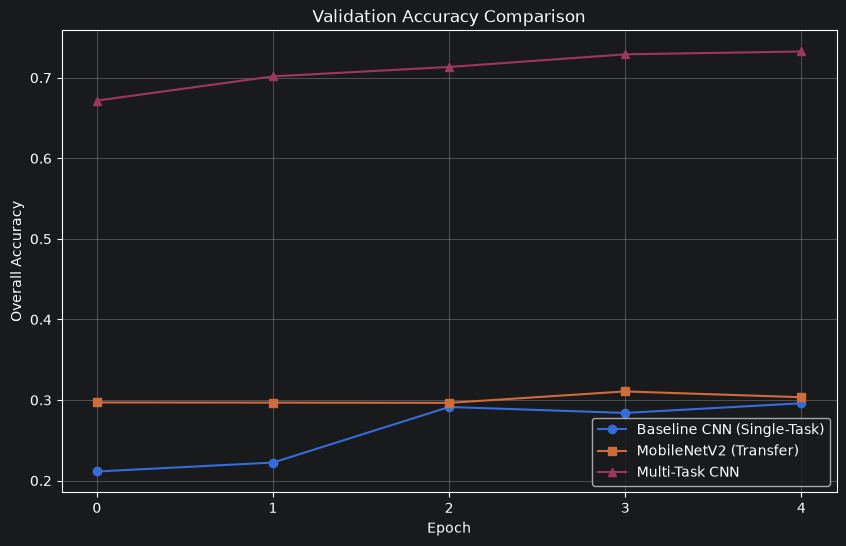


--- FAIRNESS AUDIT ---
Target predicting: 'Male'
Found 10001 validated image filenames.
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step

Subgroup: Heavy_Makeup
  Accuracy when Heavy_Makeup = 1: 98.29%
  Accuracy when Heavy_Makeup = 0: 88.94%
  Fairness Gap: 9.36%

Subgroup: Young
  Accuracy when Young = 1: 92.49%
  Accuracy when Young = 0: 92.77%
  Fairness Gap: 0.29%

Subgroup: Smiling
  Accuracy when Smiling = 1: 94.13%
  Accuracy when Smiling = 0: 91.10%
  Fairness Gap: 3.03%

Subgroup: Attractive
  Accuracy when Attractive = 1: 95.85%
  Accuracy when Attractive = 0: 89.18%
  Fairness Gap: 6.67%


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# The plotting logic remains exactly the same; it will automatically adapt to your 5 epochs instead of 10
plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN (Single-Task)', marker='o')
plt.plot(history_transfer.history['val_accuracy'], label='MobileNetV2 (Transfer)', marker='s')

# Calculates the average validation accuracy across all 6 attribute branches for the Multi-Task model
mt_val_accs = [history_multitask.history[f'val_{attr}_accuracy'] for attr in attributes]
avg_mt_val_acc = np.mean(mt_val_accs, axis=0)
plt.plot(avg_mt_val_acc, label='Multi-Task CNN', marker='^')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Overall Accuracy')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # Forces the x-axis to show whole numbers (1, 2, 3, 4, 5) to match your reduced epochs
plt.legend()
plt.grid(True)
plt.show()


print("\n--- FAIRNESS AUDIT ---")
print("Target predicting: 'Male'")

# Recreating the validation generator ensures it starts exactly from the beginning of the dataset before running predictions
val_gen_eval = val_datagen.flow_from_dataframe(
    dataframe=val_df, directory=image_dir, x_col='image_id', y_col=attributes,
    target_size=(128, 128), batch_size=32, class_mode='raw', shuffle=False
)

preds = model_transfer.predict(val_gen_eval) # Using MobileNetV2 (which usually performs best) for the required fairness audit

target_idx = attributes.index('Male')
pred_male = (preds[:, target_idx] > 0.5).astype(int) # Converts raw sigmoid probabilities above 50% into a solid binary 1 (True)
true_male = val_df['Male'].values

subgroups_to_test = ['Heavy_Makeup', 'Young', 'Smiling', 'Attractive']

for subgroup in subgroups_to_test:
    subgroup_true = val_df[subgroup].values

    mask_1 = (subgroup_true == 1) # Isolates validation images where the subgroup attribute is present
    acc_1 = np.mean(pred_male[mask_1] == true_male[mask_1])

    mask_0 = (subgroup_true == 0) # Isolates validation images where the subgroup attribute is absent
    acc_0 = np.mean(pred_male[mask_0] == true_male[mask_0])

    print(f"\nSubgroup: {subgroup}")
    print(f"  Accuracy when {subgroup} = 1: {acc_1:.2%}")
    print(f"  Accuracy when {subgroup} = 0: {acc_0:.2%}")
    print(f"  Fairness Gap: {abs(acc_1 - acc_0):.2%}") # Highlights the exact performance bias between groups

In [8]:
# Baseline single task CNN   ( with Flatten)
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input

tf.keras.backend.clear_session()

model_baseline = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='sigmoid')
])
#  SGD (Stochastic Gradient Descent) uses a single, fixed learning rate for all parameters
model_baseline.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['binary_accuracy'])
print("Baseline Model Parameters:", model_baseline.count_params())
history_baseline = model_baseline.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    shuffle=False
)

Baseline Model Parameters: 6794246
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 376s 240ms/step - binary_accuracy: 0.6761 - loss: 0.6029 - val_binary_accuracy: 0.7057 - val_loss: 0.5708
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 382s 244ms/step - binary_accuracy: 0.7497 - loss: 0.5160 - val_binary_accuracy: 0.7904 - val_loss: 0.4559
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 415s 266ms/step - binary_accuracy: 0.8000 - loss: 0.4340 - val_binary_accuracy: 0.8274 - val_loss: 0.3841
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 421s 270ms/step - binary_accuracy: 0.8224 - loss: 0.3898 - val_binary_accuracy: 0.8332 - val_loss: 0.3648
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 408s 261ms/step - binary_accuracy: 0.8307 - loss: 0.3708 - val_binary_accuracy: 0.8387 - val_loss: 0.3555
